In [11]:
import pandas as pd
import numpy as np
import os
from astropy import constants
from astropy import units as u

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [193]:
unit_dict = {}
unit_dict['ion_lum'] = u.s**(-1)
unit_dict['luminosity'] = u.Lsun
unit_dict['radius'] = u.kpc
unit_dict['gas_surface_dens'] = u.Msun/u.kpc**2
unit_dict['star_surface_dens'] = u.Msun/u.kpc**2
unit_dict['sfr_surface_dens'] = u.Msun/u.kpc**2/u.yr
unit_dict['ionizing_flux'] = u.kpc**(-2)*u.s**(-1)

In [194]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/df_snap013_lv0.pickle'
df = pd.read_pickle(path)

In [195]:
# Temporary to be removed later
df['redshift'] = 6.0107573988449

Level 1

In [197]:
Z_solar = 0.0134
df['Dust_normalized'] = df['Z']/Z_solar
df['Gas_fraction'] = df['gas_surface_dens']/(df['gas_surface_dens']+df['star_surface_dens'])
df['Galaxy_rotation_frequency'] = 0.41*(1+df['redshift'])**(2/3)

df['Bolometric_flux'] = df['luminosity']/(np.pi*df['radius']**2)
unit_dict['Bolometric_flux'] = unit_dict['luminosity']/(unit_dict['radius']**2)

Level 2

In [198]:
df['Velocity_dispersion'] = df['sfr_surface_dens']/(df['Gas_fraction']*df['Galaxy_rotation_frequency'])**2
unit_dict['Velocity_dispersion'] = u.km/u.s

df['Critical_column_dens'] = 4.3e20/df['Dust_normalized']
unit_dict['Critical_column_dens'] = u.cm**(-2)

df['Gravitational_pressure'] = np.pi/2*constants.G.value*df['gas_surface_dens']**2/df['Gas_fraction']
unit_dict['Gravitational_pressure'] = constants.G.unit*unit_dict['gas_surface_dens']**2

df['Dust_cross_per_H'] = 4.8e-22*df['Dust_normalized']
unit_dict['Dust_cross_per_H'] = u.cm**2

Level 3

In [199]:
df['Column_height'] = df['Velocity_dispersion']**2/(np.pi*constants.G.value*(df['gas_surface_dens']+df['star_surface_dens']))
unit_dict['Column_height'] = unit_dict['Velocity_dispersion']**2/(constants.G.unit*unit_dict['gas_surface_dens'])

Level 4

In [200]:
mu = 1 #Mean molecular weight to be adjusted later
df['Particle_dens'] = df['gas_surface_dens']/(mu*constants.m_p.value*df['Column_height'])
unit_dict['Particle_dens'] = unit_dict['gas_surface_dens']/(constants.m_p.unit*unit_dict['Column_height'])

Level 5

In [283]:
unit_dict['Particle_dens'].to(u.cm**(-3))

4.361236517333223e-30

In [286]:
unit_dict['ionizing_flux']

Unit("1 / (kpc2 s)")

In [285]:
unit_dict['ionizing_flux'].to(u.cm**(-2)*u.s**(-1))

1.0502650403056095e-43

In [279]:
unit_corr_photon_to_gas

2.408181799201796e-16

In [201]:
unit_corr_photon_to_gas = float(1*unit_dict['ionizing_flux']/(unit_dict['Particle_dens']*constants.c.unit))
df['Photon_to_gas'] = df['ionizing_flux']/(df['Particle_dens']*constants.c.value)*unit_corr_photon_to_gas

df['Gas_column_dens'] = df['Particle_dens']*df['Column_height']
unit_dict['Gas_column_dens'] = unit_dict['Particle_dens']*unit_dict['Column_height']

Level 6

In [202]:
df['U1'] = df['Gas_fraction']**3*df['Photon_to_gas']

case_B_param = 2.6e-13*u.cm**3/u.s
df['Column_dens_stroemgren'] = df['Gas_fraction']*constants.c.value/case_B_param.value
unit_dict['Column_dens_stroemgren'] = constants.c.unit/case_B_param.unit

unit_corr_optical_depth = float(1*unit_dict['Dust_cross_per_H']*unit_dict['Gas_column_dens'])
df['Optical_depth'] = df['Dust_cross_per_H']*df['Gas_column_dens']*unit_corr_optical_depth

Level 7

In [203]:
df['Radiation_pressure'] = (1-np.exp(-1*df['Optical_depth']))*df['Bolometric_flux']/constants.c.value
unit_dict['Radiation_pressure'] = unit_dict['Bolometric_flux']/constants.c.unit

N_ratio_corr = float(1*unit_dict['Gas_column_dens']/unit_dict['Critical_column_dens'])
df['N_ratio'] = df['Gas_column_dens']/df['Critical_column_dens']*N_ratio_corr

Level 8

In [220]:
def outflow_velocity(element):
    return (2*element['Column_height']*(element['Radiation_pressure']-element['Gravitational_pressure'])/element['gas_surface_dens'])**0.5

In [222]:
unit_corr_rad_pressure = unit_dict['Radiation_pressure'].to(u.Pa)
unit_corr_grav_pressure = unit_dict['Gravitational_pressure'].to(u.Pa)

df['Radiation_pressure'] = df['Radiation_pressure']*unit_corr_rad_pressure
df['Gravitational_pressure'] = df['Gravitational_pressure']*unit_corr_grav_pressure

unit_dict['Radiation_pressure'] = u.Pa
unit_dict['Gravitational_pressure'] = u.Pa

#df['Outflow_velocity'] = (2*df['Column_height']*(df['Radiation_pressure']-df['Gravitational_pressure'])/df['gas_surface_dens'])**0.5
df['Outflow_velocity'] = df.apply(lambda x: 0 if x['Radiation_pressure']<x['Gravitational_pressure'] else outflow_velocity(x), axis=1)
unit_dict['Outflow_velocity'] = (unit_dict['Column_height']*unit_dict['Radiation_pressure']/unit_dict['gas_surface_dens'])**0.5

df['Critical_gas_fraction'] = 6*(df['Dust_normalized']*df['U1']*((1-df['N_ratio'])/df['N_ratio']))

Level 9

In [223]:
t_OB = 2*u.Myr
df['Reduced_column_dens'] = (1-0.5*df['Outflow_velocity']*t_OB.value/df['Column_height'])*df['Gas_column_dens']
unit_dict['Reduced_column_dens'] = unit_dict['Outflow_velocity']*t_OB.unit/unit_dict['Column_height']*unit_dict['Gas_column_dens']

In [224]:
def escape_fraction(element):
    return np.exp(-element['Reduced_column_dens']*(1/element['Column_dens_stroemgren']+1/element['Critical_column_dens']))   

Level 10

In [225]:
unit_corr_reduced_colum_dens = unit_dict['Reduced_column_dens'].to(u.cm**(-2))
unit_corr_column_dens_stroemgren = unit_dict['Column_dens_stroemgren'].to(u.cm**(-2))
unit_corr_crit_column_dens = unit_dict['Critical_column_dens'].to(u.cm**(-2))

unit_dict['Reduced_column_dens'] = u.cm**(-2)
unit_dict['Column_dens_stroemgren'] = u.cm**(-2)
unit_dict['Critical_column_dens'] = u.cm**(-2)

df['Reduced_column_dens'] = df['Reduced_column_dens']*unit_corr_reduced_colum_dens
df['Column_dens_stroemgren'] = df['Column_dens_stroemgren']*unit_corr_column_dens_stroemgren
df['Column_dens_stroemgren'] = df['Column_dens_stroemgren']*unit_corr_crit_column_dens

df['escape_fraction'] = df.apply(lambda x: 0 if x['Gas_fraction']<x['Critical_gas_fraction'] else escape_fraction(x), axis=1)

In [186]:
from matplotlib import pyplot as plt

In [245]:
df['break_out'] = df['Gas_fraction']<df['Critical_gas_fraction']

In [ ]:
df['Column_height'] = df['Velocity_dispersion']**2/(np.pi*constants.G.value*(df['gas_surface_dens']+df['star_surface_dens']))

In [304]:
unit_dict['Velocity_dispersion']

Unit("km / s")

In [ ]:
df['Gas_fraction']*df['Galaxy_rotation_frequency']

In [315]:
unit_dict['sfr_surface_dens']

Unit("solMass / (kpc2 yr)")

In [321]:
df['Velocity_dispersion'].describe()

count    2.813430e+05
mean     1.138041e-04
std      4.580228e-02
min      6.740845e-12
25%      8.899315e-09
50%      3.006616e-08
75%      8.505709e-08
max      2.328472e+01
Name: Velocity_dispersion, dtype: float64

In [326]:
df['SFR'].describe()

count    281343.000000
mean          0.011099
std           0.987096
min           0.000006
25%           0.000121
50%           0.000389
75%           0.001340
max         391.632721
Name: SFR, dtype: float64

In [329]:
unit_dict['radius']

Unit("kpc")

In [328]:
df['radius'].describe()

count    281343.000000
mean         62.083375
std          45.641016
min           3.483111
25%          35.753074
50%          50.638866
75%          73.463461
max        2437.265626
Name: radius, dtype: float64

(1e-10, 0.0001)

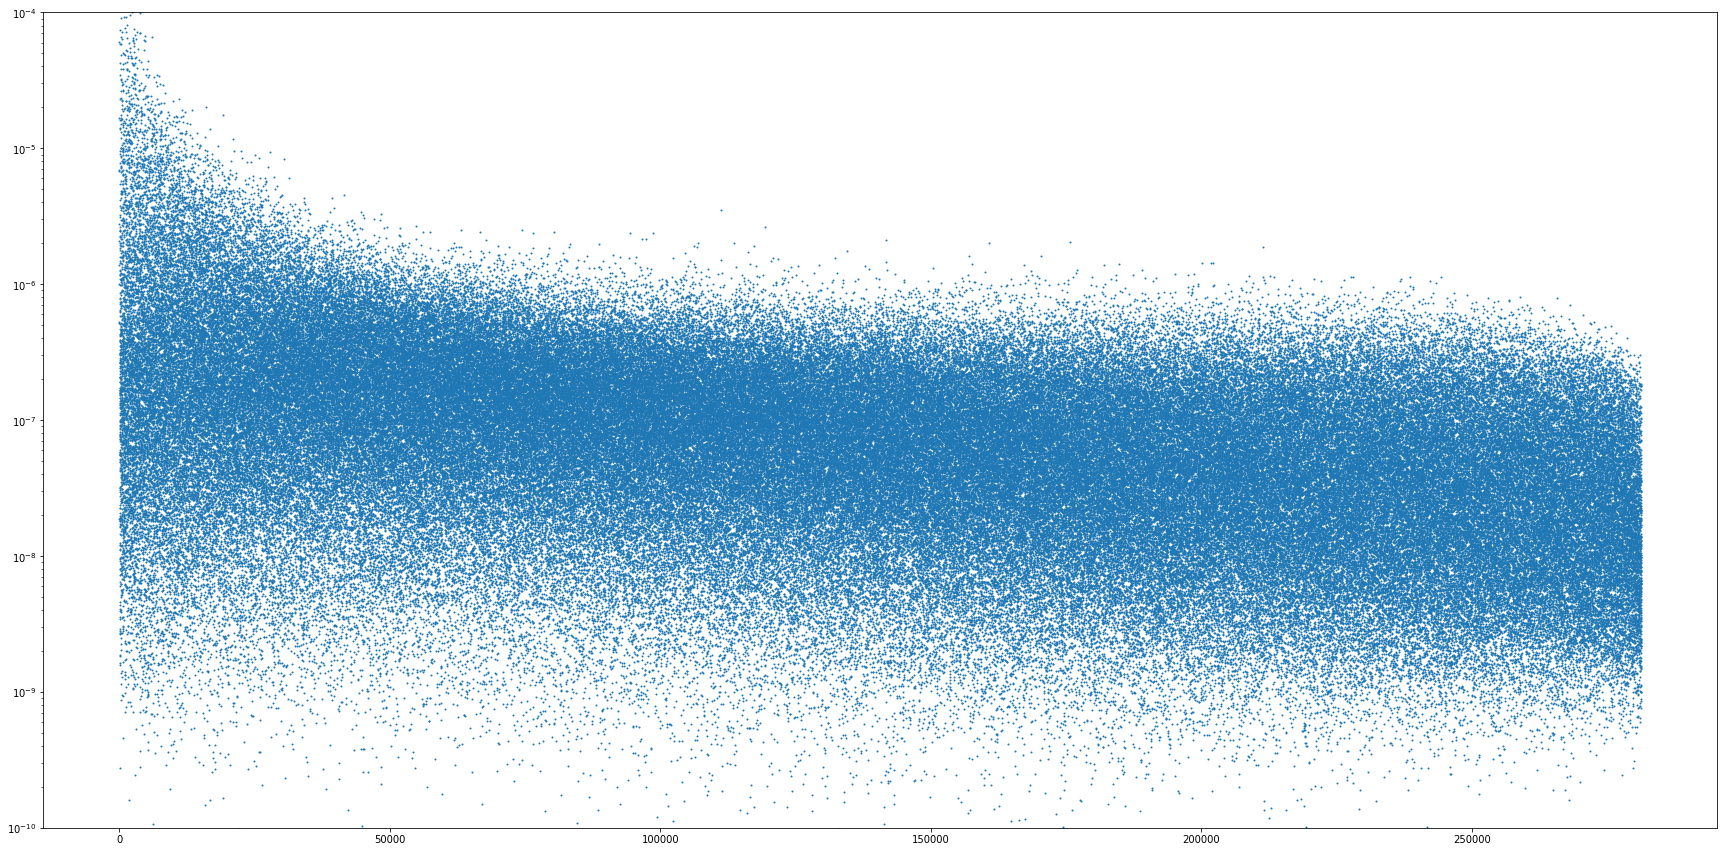

In [323]:
plt.scatter(np.arange(len(df)), df['sfr_surface_dens'], s=1)
plt.yscale('log')
plt.ylim(1e-10,1e-4)

In [331]:
df['Gas_fraction'].describe()

count    281343.000000
mean          0.942044
std           0.064248
min           0.008948
25%           0.931348
50%           0.958742
75%           0.975855
max           0.999309
Name: Gas_fraction, dtype: float64

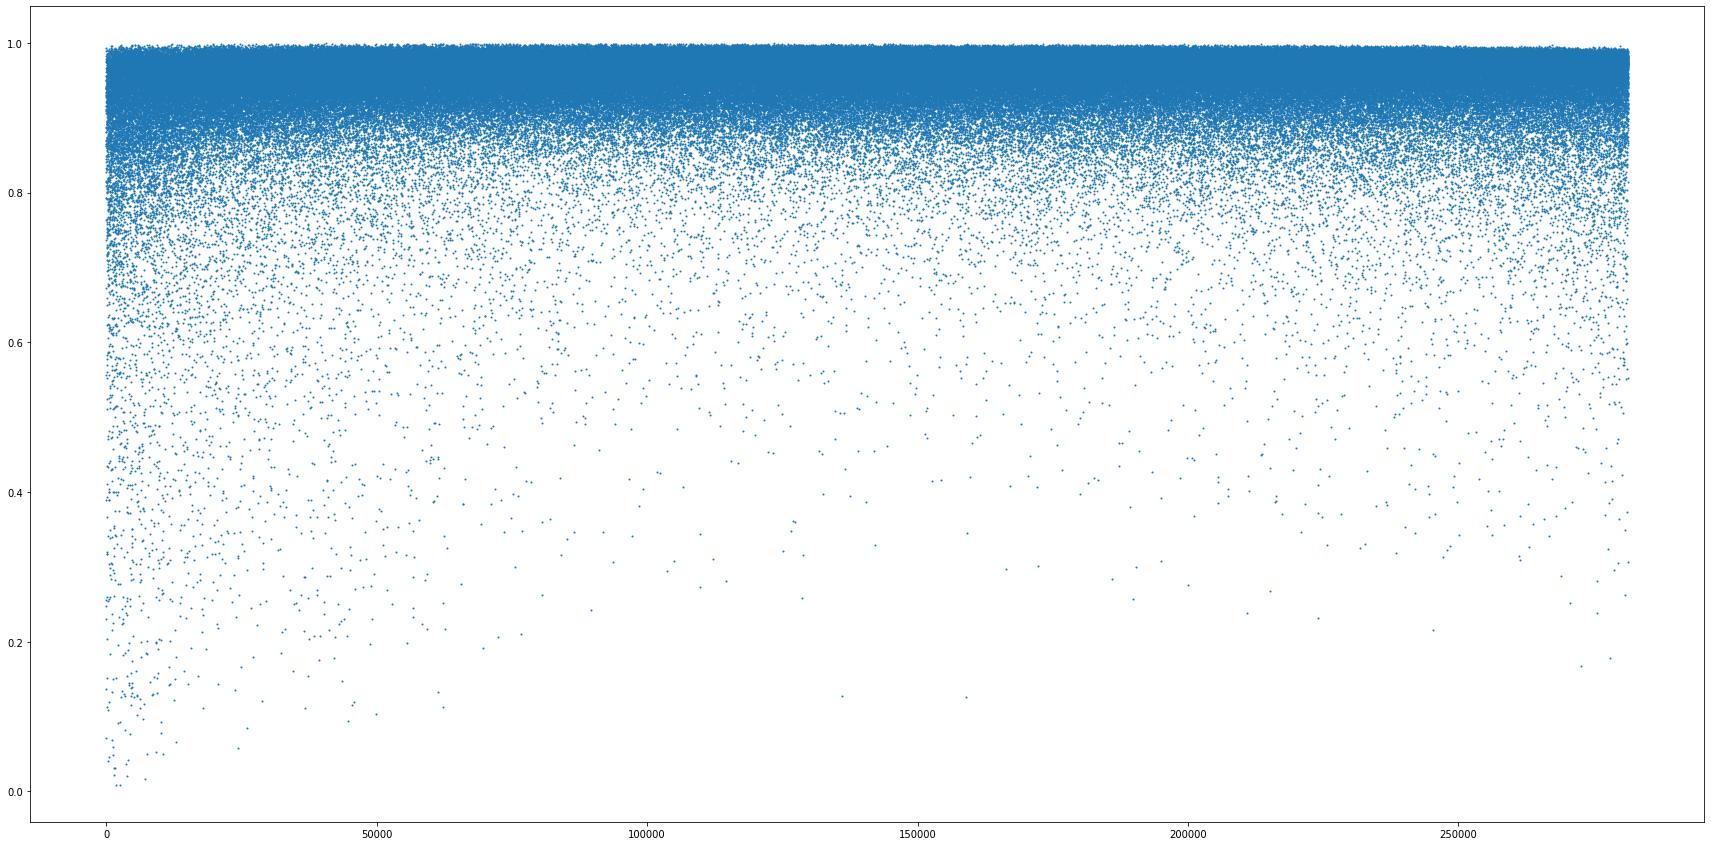

In [332]:
plt.scatter(np.arange(len(df)), df['Gas_fraction'], s=1)
#plt.ylim(1e-10,1e2)

In [319]:
3e-3/(0.2*0.04**2)

9.375

(1e+25, 5e+38)

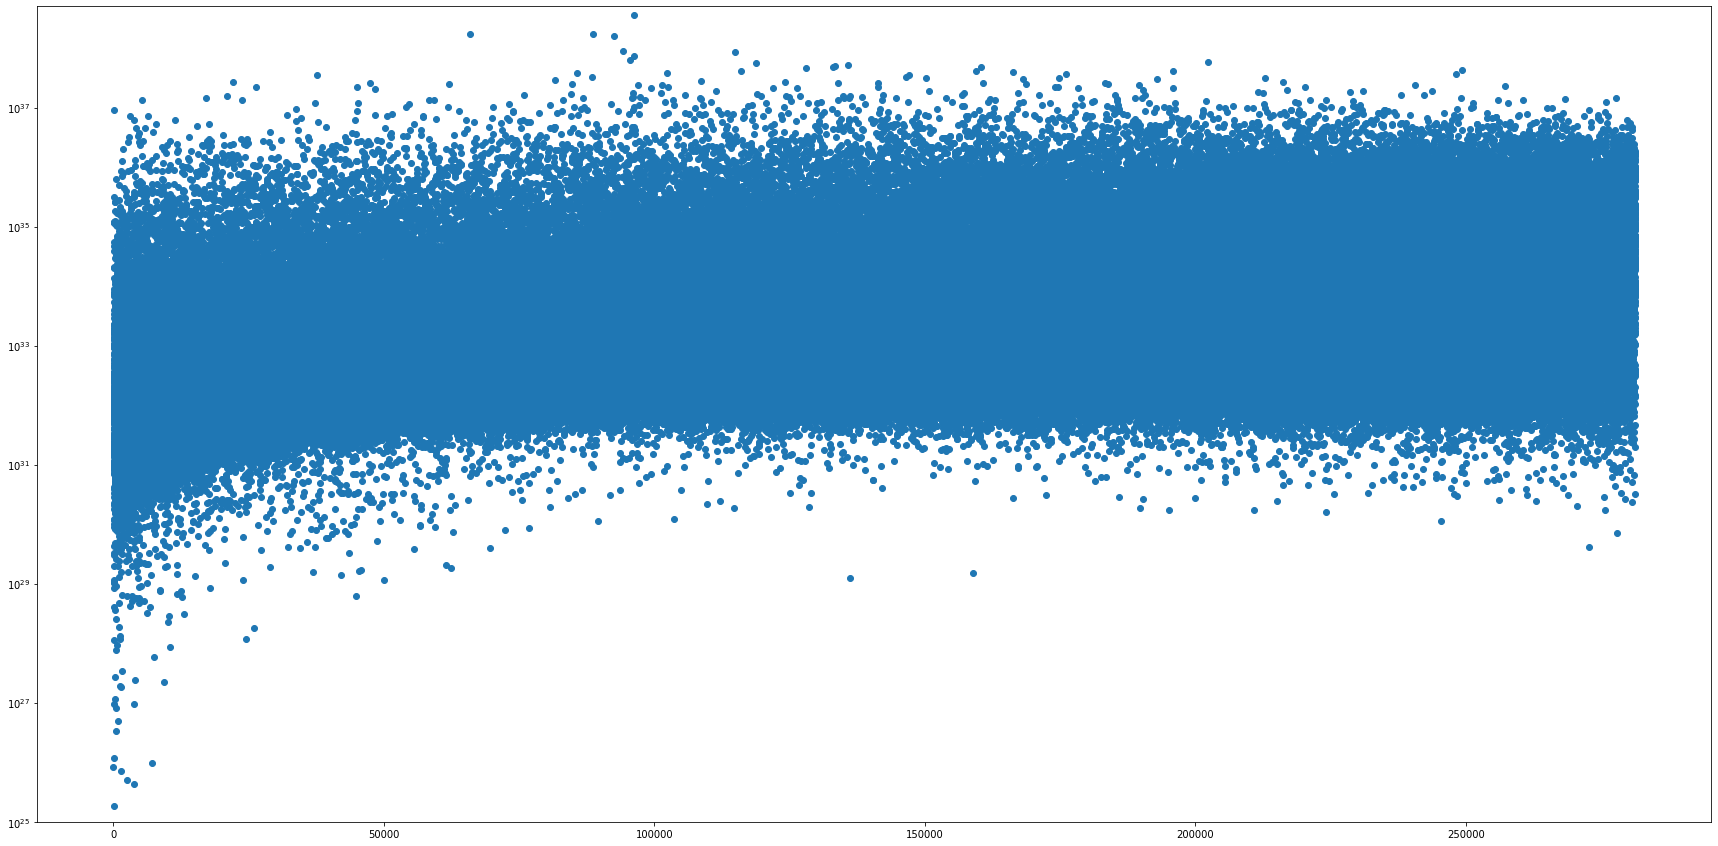

In [300]:
mult_height = unit_dict['Column_height'].to(u.kpc)
plt.scatter(np.arange(len(df)), df['Particle_dens']*mult_height)
plt.yscale('log')
plt.ylim(1e25,5e38)

(1, 110000000000000.0)

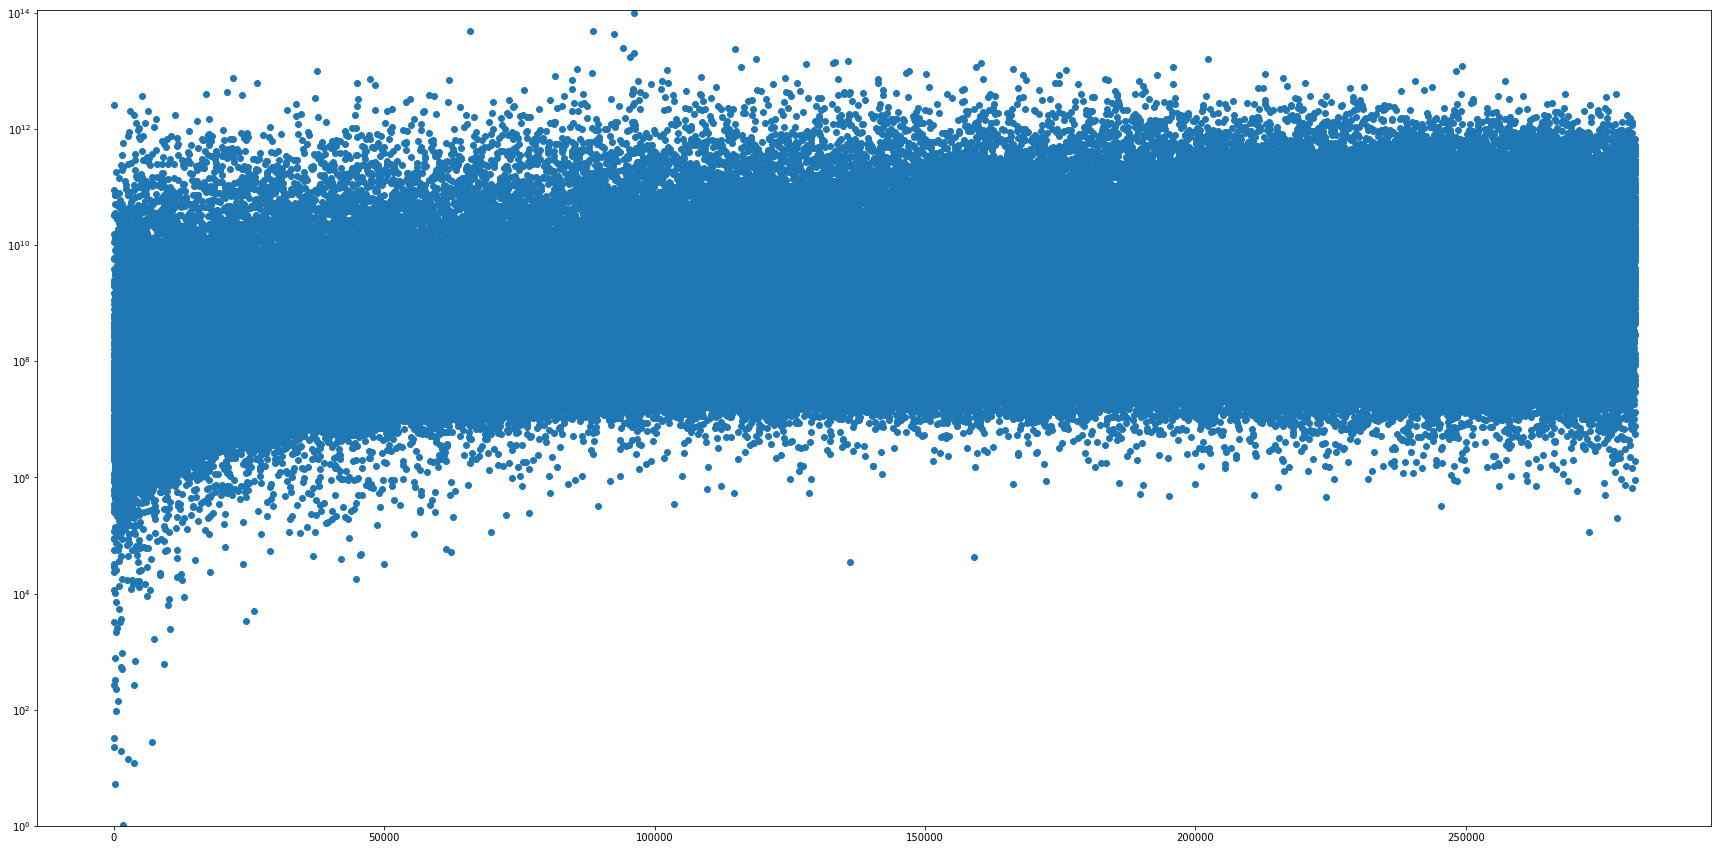

In [290]:
mult = unit_dict['Particle_dens'].to(u.cm**(-3))
plt.scatter(np.arange(len(df)), df['Particle_dens']*mult)
plt.yscale('log')
plt.ylim(1,1.1e14)

(1e-30, 11.0)

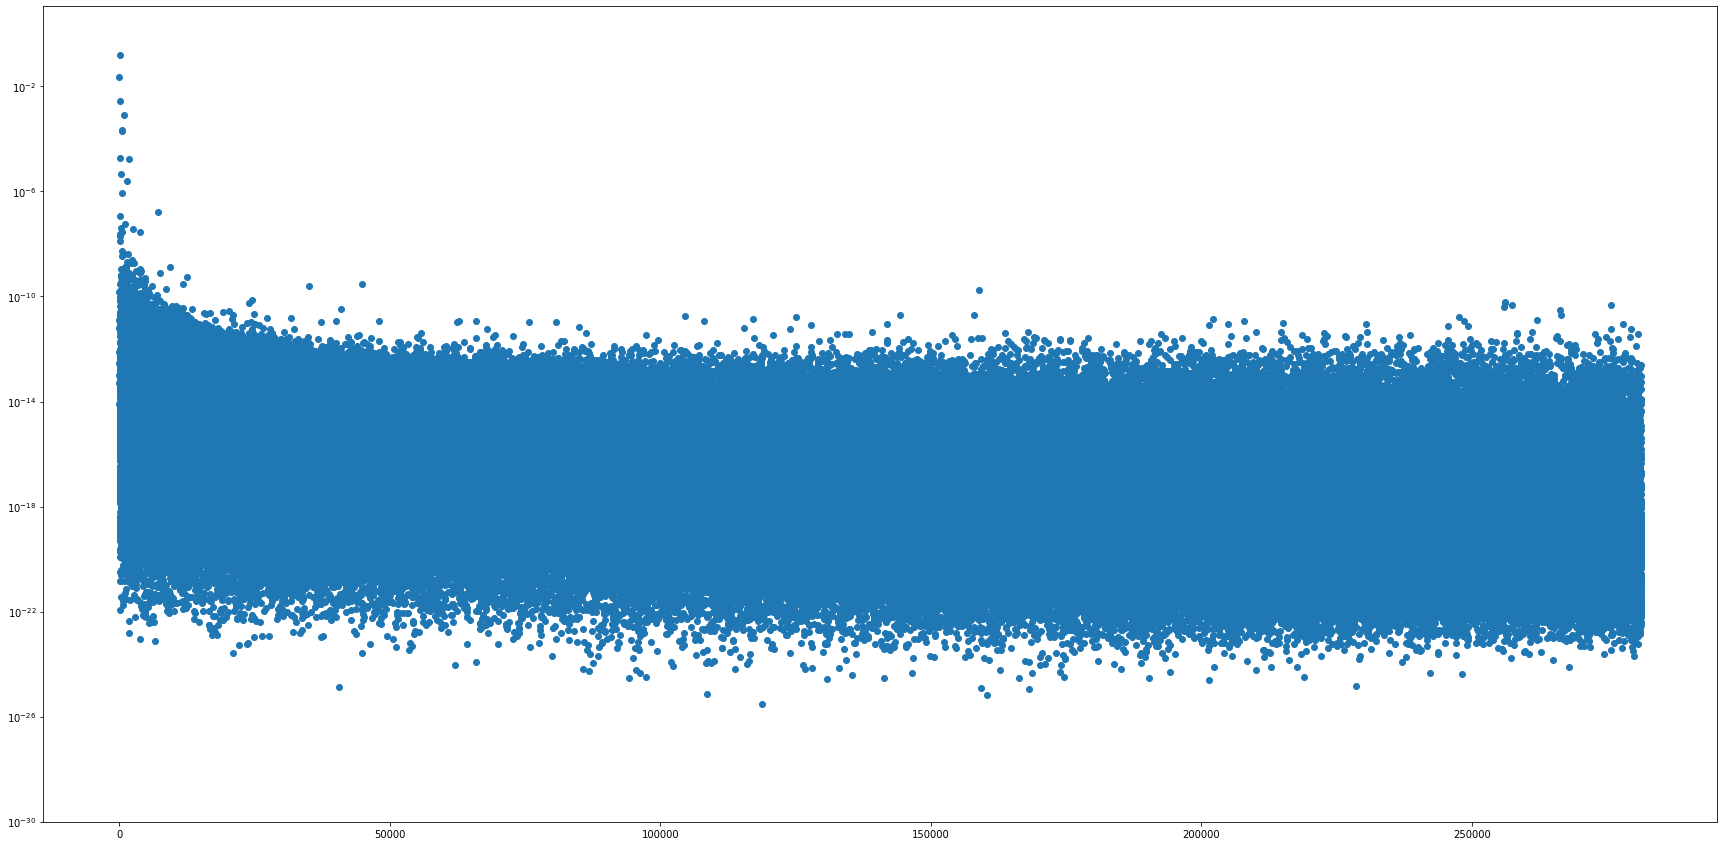

In [278]:
plt.scatter(np.arange(len(df)), df['Photon_to_gas'])
plt.yscale('log')
plt.ylim(1e-30,1.1e1)

(1e-20, 30.0)

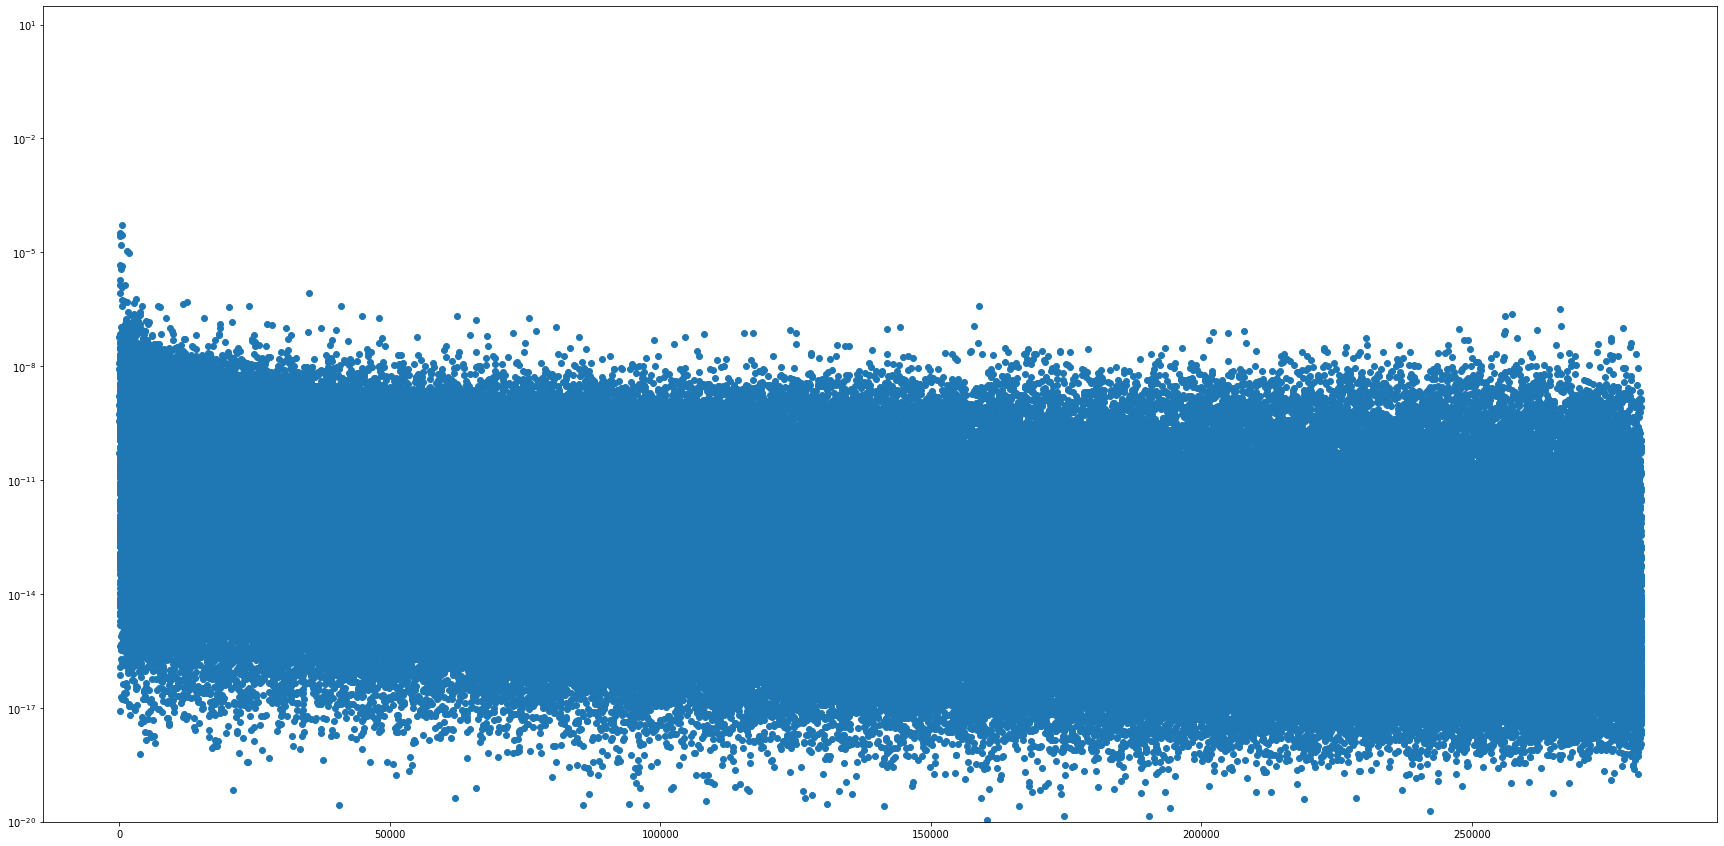

In [252]:
plt.scatter(np.arange(len(df)), df['Critical_gas_fraction'])
plt.yscale('log')
plt.ylim(1e-20,3e1)

(0.1, 3e+20)

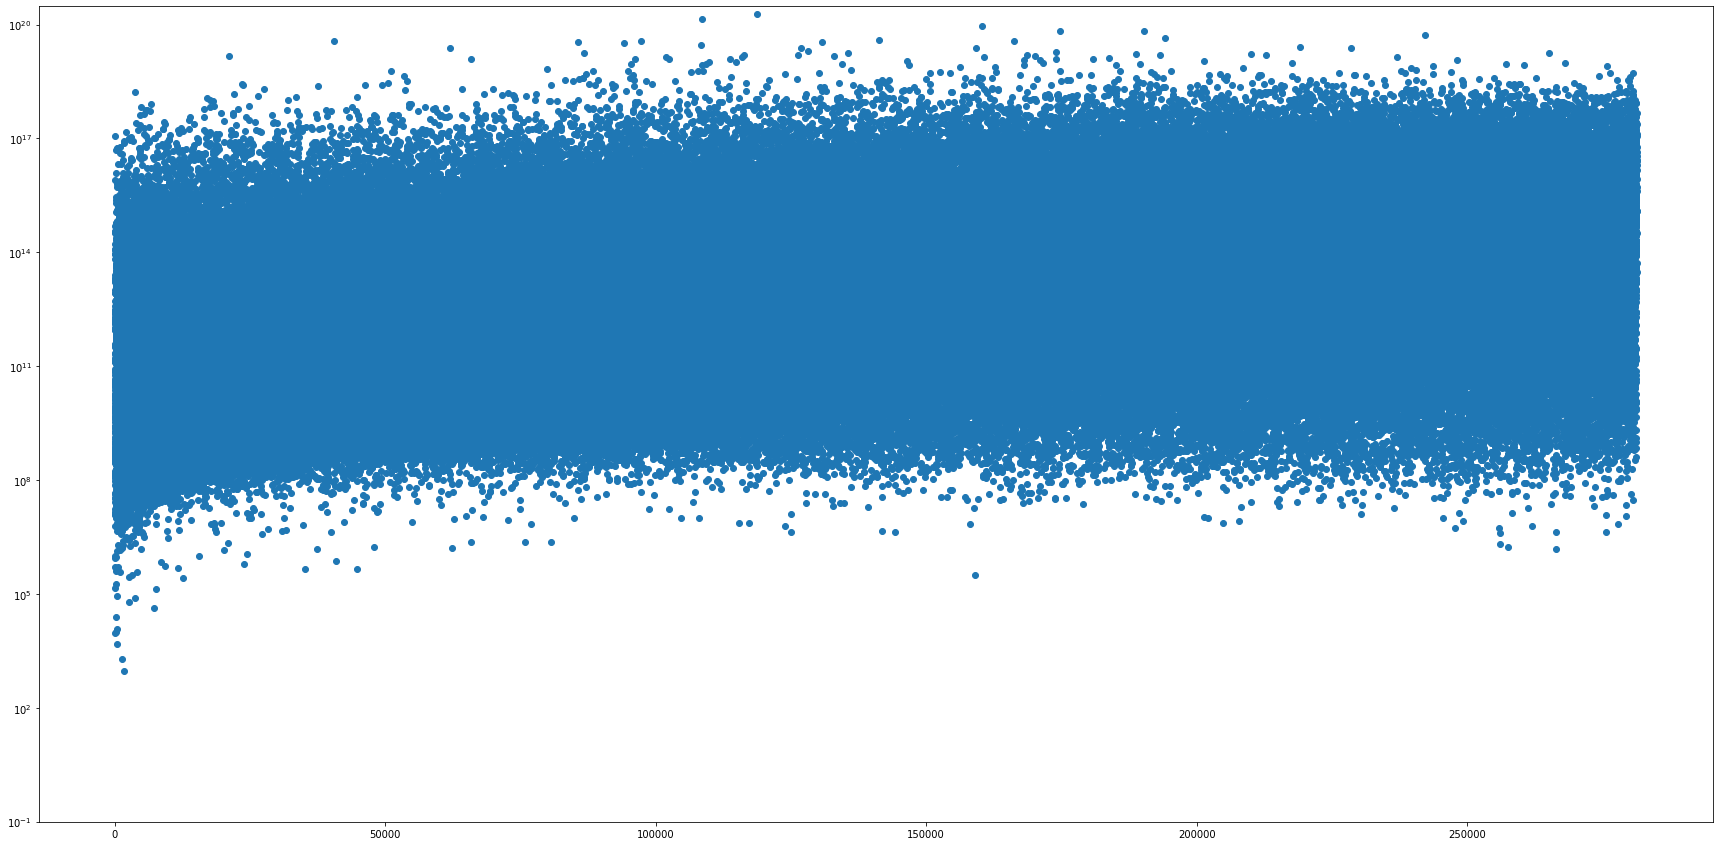

In [249]:
plt.scatter(np.arange(len(df)), df['Gas_fraction']/df['Critical_gas_fraction'])
plt.rcParams['figure.figsize'] = [30, 15]
plt.yscale('log')
plt.ylim(1e-1,3e20)

In [171]:
df[df['Outflow_velocity'] > 0]['HaloMass'].mean()

0.104005374

In [293]:
9.9e-30/constants.m_p.value

0.005918851032491215

In [158]:
unit_dict['Gravitational_pressure'].to(u.Pa)

4.3612365173332226e-18

In [160]:
df['Gravitational_pressure']

0          207319.464454
1               0.031390
2               0.009021
3               0.000770
4               0.003322
               ...      
2368557         0.000052
2422910         0.000050
2434511         0.000016
2521336         0.000028
2745125         0.000081
Name: Gravitational_pressure, Length: 281343, dtype: float64

In [161]:
df['Radiation_pressure']

0          2.159843e+01
1          1.610043e-07
2          9.267364e-08
3          5.763644e-10
4          2.250407e-08
               ...     
2368557    5.426146e-12
2422910    2.179846e-12
2434511    2.297078e-13
2521336    4.538076e-13
2745125    6.168920e-13
Name: Radiation_pressure, Length: 281343, dtype: float64

In [155]:
for idx in df.index:
    if idx < 1000:
        print((2*df.loc[idx]['Column_height']*(df.loc[idx]['Radiation_pressure']-df.loc[idx]['Gravitational_pressure'])/df.loc[idx]['gas_surface_dens'])**0.5)
    else:
        break

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


<ipython-input-155-a117f0ae8552>:3: RuntimeWarning: invalid value encountered in double_scalars
  print((2*df.loc[idx]['Column_height']*(df.loc[idx]['Radiation_pressure']-df.loc[idx]['Gravitational_pressure'])/df.loc[idx]['gas_surface_dens'])**0.5)


In [122]:
unit_dict['Radiation_pressure'].to(u.Pa)

UnitConversionError: 's solLum / m' (force) and 'Pa' (pressure) are not convertible

In [123]:
unit_dict['Gravitational_pressure'].to(u.Pa)

4.3612365173332226e-18

In [115]:
(u.kg*u.m**2/u.s**3)**0.5*u.s**1.5/u.kg**0.5/u.m**2

Unit("1 / m")

In [110]:
 unit_dict['Column_dens_stroemgren']

Unit("m / cm3")

In [106]:
unit_corr_column_dens_stroemgren = unit_dict['Column_dens_stroemgren'].to(u.cm**(-2))

In [107]:
unit_corr_crit_column_dens = unit_dict['Critical_column_dens'].to(u.cm**(-2))

In [108]:
unit_corr_column_dens_stroemgren

99.99999999999999

In [109]:
unit_corr_crit_column_dens

1.0

In [334]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/testing/sn013.pickle'
test = pd.read_pickle(path)

In [335]:
test

SubhaloGasMetallicity SubhaloGasMetallicityHalfRad  \
                            0                            0   
0                    0.015532                     0.017928   
1                    0.002725                     0.003610   
2                    0.004793                     0.007448   
3                    0.001956                     0.003759   
4                    0.005315                     0.007526   
...                       ...                          ...   
2368557              0.000578                     0.000597   
2422910              0.000685                     0.000708   
2434511              0.000441                     0.000514   
2521336              0.000406                     0.000402   
2745125              0.000327                     0.000355   

        SubhaloHalfmassRadType SubhaloMassInHalfRad SubhaloMassInHalfRadType  \
                             4                    0                        4   
0                     0.595610             1.791372                 1.380728   
1                     8.928092             0.336186                 0.008784   
2                     6.140252             0.103683                 0.005299   
3                    13.317231             0.193574                 0.002193   
4                     5.533516             0.065053                 0.002343   
...                        ...                  ...                      ...   
2368557               1.293625             0.000540                 0.000004   
2422910               2.607095             0.000968                 0.000003   
2434511               3.430640             0.001582                 0.000003   
2521336               2.234654             0.000920                 0.000003   
2745125               1.533991             0.000673                 0.000002   

        SubhaloMassInRad SubhaloMassInRadType           SubhaloSFRinHalfRad  \
                       0                    0         4                   0   
0               3.268400             0.690410  2.306308          224.748779   
1               0.796984             0.119877  0.012056            1.461907   
2               0.261141             0.028767  0.006582            0.276816   
3               0.471234             0.042249  0.003220            0.078287   
4               0.171911             0.014199  0.003198            0.087283   
...                  ...                  ...       ...                 ...   
2368557         0.001249             0.000103  0.000009            0.000017   
2422910         0.002738             0.000422  0.000010            0.000032   
2434511         0.003374             0.000415  0.000008            0.000016   
2521336         0.002144             0.000232  0.000007            0.000026   
2745125         0.001759             0.000186  0.000005            0.000042   

        SubhaloSFRinRad    SubhaloPos                              
                      0             0             1             2  
0            391.632721  24135.921875  18115.128906  14856.313477  
1              1.798865  24471.667969  18013.396484  14240.319336  
2              0.346269  24264.136719  18214.417969  14564.745117  
3              0.122709  24364.863281  18031.574219  14490.092773  
4              0.115020  24437.298828  17996.375000  14386.402344  
...                 ...           ...           ...           ...  
2368557        0.000017  21072.396484  20731.857422  19424.056641  
2422910        0.000032  25230.380859  18890.257812  30166.308594  
2434511        0.000016  15592.056641   5091.797852  17122.677734  
2521336        0.000026  12621.503906  19735.369141  14953.285156  
2745125        0.000059  20371.802734  28411.167969  10255.405273  

[281349 rows x 13 columns]